<a href="https://colab.research.google.com/github/Sudhar-san24/DataScience-Course/blob/main/UnsupervisedLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Market Basket Aanalysis MBA

In [12]:
import pandas as pd

In [13]:
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

In [14]:
df=pd.DataFrame({
    'Milk':[1,1,1,1,1],
    'Bread':[1,0,1,0,1],
    'Beer':[0,1,0,0,1],
    'Eggs':[1,0,0,0,1],
    'Coke':[1,0,1,0,1],
    'Bread':[0,0,1,1,1]
})

In [15]:
df

,Milk,Bread,Beer,Eggs,Coke
0,1,0,0,1,1
1,1,0,1,0,0
2,1,1,0,0,1
3,1,1,0,0,0
4,1,1,1,1,1


In [17]:
frequent_itemsets = fpgrowth(df , min_support=0.1, use_colnames=True)
print(frequent_itemsets)

    support                         itemsets
0       1.0                           (Milk)
1       0.6                           (Coke)
2       0.4                           (Eggs)
3       0.4                           (Beer)
4       0.6                          (Bread)
5       0.6                     (Milk, Coke)
6       0.4                     (Coke, Eggs)
7       0.4                     (Milk, Eggs)
8       0.2                     (Beer, Eggs)
9       0.2                    (Bread, Eggs)
10      0.4               (Milk, Coke, Eggs)
11      0.2               (Beer, Coke, Eggs)
12      0.2              (Bread, Coke, Eggs)
13      0.2               (Milk, Beer, Eggs)
14      0.2              (Milk, Bread, Eggs)
15      0.2              (Bread, Beer, Eggs)
16      0.2         (Milk, Beer, Coke, Eggs)
17      0.2        (Milk, Bread, Coke, Eggs)
18      0.2        (Bread, Beer, Coke, Eggs)
19      0.2        (Beer, Milk, Bread, Eggs)
20      0.2  (Coke, Milk, Beer, Bread, Eggs)
21      0.

In [18]:
frequent_itemsets = fpgrowth(df , min_support=0.6, use_colnames=True)
frequent_itemsets

,support,itemsets
0,1.0,(Milk)
1,0.6,(Coke)
2,0.6,(Bread)
3,0.6,"(Milk, Coke)"
4,0.6,"(Milk, Bread)"


In [21]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
rules

/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Milk),(Coke),1.0,0.6,0.6,0.6,1.0,1.0,0.0,1.0,0.0,0.6,0.0,0.8
1,(Coke),(Milk),0.6,1.0,0.6,1.0,1.0,1.0,0.0,inf,0.0,0.6,0.0,0.8
2,(Milk),(Bread),1.0,0.6,0.6,0.6,1.0,1.0,0.0,1.0,0.0,0.6,0.0,0.8
3,(Bread),(Milk),0.6,1.0,0.6,1.0,1.0,1.0,0.0,inf,0.0,0.6,0.0,0.8


KMeans

In [31]:
import numpy as np
import pandas as pd

In [32]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

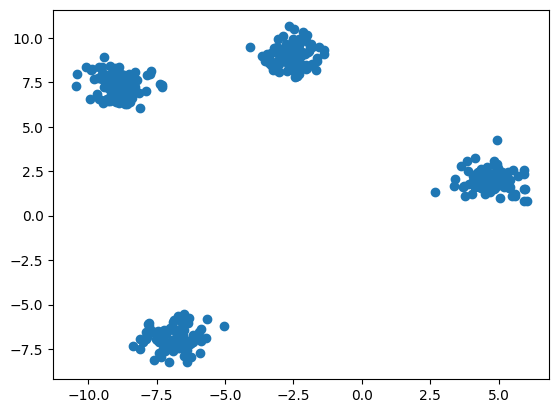

In [33]:
#Generate sample data
x,cluster =make_blobs(n_samples=400, centers=4, cluster_std=0.60, random_state=42)
plt.scatter(x[:,0], x[:,1])
plt.show()

In [34]:
kmeans = KMeans (n_clusters=4 ,random_state=42)
kmeans.fit(x)
print(kmeans)

KMeans(n_clusters=4, random_state=42)


In [35]:
cluster_kmeans=kmeans.predict(x)
print(cluster_kmeans)
centeroids=kmeans.cluster_centers_
print(centeroids)

[1 3 1 0 0 3 3 1 3 0 1 0 1 0 2 2 2 3 0 2 0 1 3 0 3 1 2 3 2 1 1 0 1 1 3 2 0
 0 3 2 3 1 1 2 0 0 3 2 3 0 3 1 2 0 0 1 0 3 1 0 2 0 1 2 3 3 2 2 2 1 3 2 1 0
 1 3 1 2 3 3 2 3 1 1 2 0 1 2 3 2 0 3 1 2 0 1 1 2 2 3 2 0 3 2 2 2 0 2 0 3 3
 1 0 0 1 1 1 0 1 3 2 0 1 3 1 2 2 0 2 3 3 3 2 1 2 1 3 2 3 2 3 2 2 0 3 1 2 3
 1 0 1 3 2 0 2 3 0 3 0 3 0 3 0 1 0 1 2 1 1 1 1 3 2 2 2 0 0 3 0 1 2 0 0 0 2
 0 3 3 2 2 0 1 1 0 2 2 1 2 1 1 0 3 2 3 3 0 1 3 1 2 3 0 0 3 0 2 2 0 3 0 2 3
 3 0 2 3 2 3 2 3 2 3 0 1 1 2 1 1 0 2 3 3 1 3 2 2 0 3 0 0 0 0 3 2 0 2 3 0 1
 1 3 0 0 1 1 2 2 2 3 0 0 2 2 0 3 2 3 3 0 1 3 0 2 1 3 3 1 1 1 0 0 1 0 0 2 1
 3 3 0 1 1 0 1 2 0 1 0 1 1 3 3 3 1 2 3 3 2 3 2 2 2 2 1 1 0 2 1 3 0 3 3 2 3
 0 1 2 1 3 3 1 1 2 0 3 1 0 0 1 1 3 0 0 1 0 1 0 0 3 0 3 1 1 2 2 1 2 0 2 2 1
 3 1 1 1 3 2 0 2 2 2 3 0 2 1 1 0 3 0 2 1 3 1 3 3 1 0 0 2 0 3]
[[ 4.70421356  1.99562444]
 [-8.89285773  7.35858557]
 [-6.88217395 -6.94243433]
 [-2.58361866  9.03185632]]


In [36]:
score=silhouette_score(x,cluster_kmeans)
print("silhouette_score",score)

silhouette_score 0.876354521706931


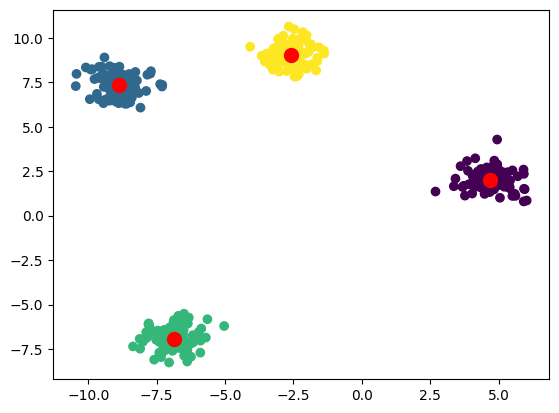

In [37]:
plt.scatter(x[:,0], x[:,1], c=cluster_kmeans)
plt.scatter(centeroids[:,0], centeroids[:,1], s=100, c='red')

In [45]:
interia_vlaues=[]
K= range(1,10)
for k in K:
  kmeans=KMeans(n_clusters=k, random_state=42)
  kmeans.fit(x)
  interia_vlaues.append(kmeans.inertia_)


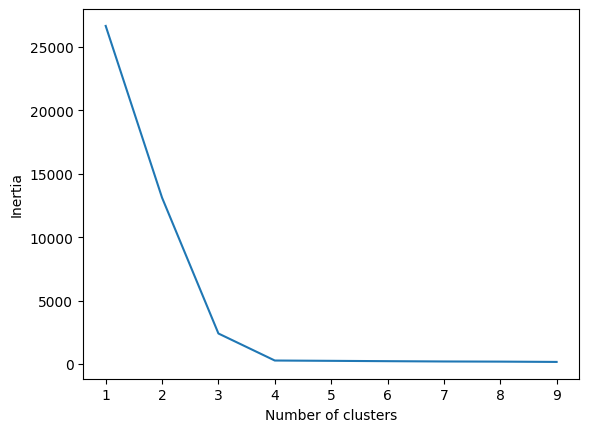

In [46]:
plt.plot(K,interia_vlaues)
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()